In [1]:
# 2016-2018 - train, 2019 - eval, 2020 - test
DISTRIBUTION = {
    'train': [
        26667849, 26678314, 26688349, 26688350, 26580716, 26580717, 26656254, 26675821,  # 2016
        27834397, 27834398, 27890914, 27916977, 27677859, 27677860, 27904142, 28003656,  # 2017
        29147025, 29170536, 28853444, 28920587, 28792006, 28852220, 29213134, 29321682   # 2018
    ],
    'eval': [
        30578414, 30842595, 30644449, 30679807, 30108335, 30390028, 30459365, 30467385   # 2019
    ],
    'test': [
        31686003, 31806885, 31836872, 32005979, 31937935, 32020081, 32042144, 32699292   # 2020
    ]
}

## Pair Classification

Each pair of references either belongs to the same cluster or not, let's try binary classification.

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

from utils.io import load_analyzer, load_clustering
from utils.preprocessing import preprocess_clustering

In [3]:
def get_pairs_dataframe(pmid, analyzer, ground_truth):
    pairs = []

    # Get all pairs of references that have ground truth clusters
    ground_truth_pmids = sorted(ground_truth.keys())
    n_pmids = len(ground_truth_pmids)
    for key1 in ground_truth_pmids:
        for key2 in ground_truth_pmids:
            if key1 < key2:
                pairs.append((pmid, n_pmids, key1, key2, ground_truth[key1] == ground_truth[key2]))
    pairs_df = pd.DataFrame(pairs, columns=['review_id', 'n_references', 'id_1', 'id_2', 'same_cluster'])
    
    # Count total number of cocitations, in which each paper is involved
    cocit_data = dict(analyzer.similarity_graph.degree(weight='cocitation'))
    cocit_df = pd.DataFrame(cocit_data.items(), columns=['id', 'cocit'])
    
    # Take only essential data about papers (TODO: analyze texts)
    df = analyzer.df[analyzer.df.id.isin(ground_truth_pmids)][['id', 'year', 'abstract', 'total']].merge(cocit_df, on='id')
    
    # Extract values from edges of similarity graph
    similarity_data = []

    for id_1, id_2, data in analyzer.similarity_graph.edges(data=True):
        similarity_data.append((id_1, id_2, 
                                data.get('cocitation', 0),
                                data.get('bibcoupling', 0),
                                data.get('citation', 0),
                                data.get('text', 0)))
    similarity_df = pd.DataFrame(similarity_data, 
                                 columns=['id_1', 'id_2', 'cocitation', 'bibcoupling', 'citation', 'text'])
    
    # Merge all info to the pairs dataframe
    full_df = pairs_df.merge(df, left_on='id_1', right_on='id')\
                      .merge(df, left_on='id_2', right_on='id')\
                      .merge(similarity_df, on=['id_1', 'id_2'])
    full_df = full_df.drop(columns=['id_x', 'id_y'])
    
    # Calculate additional values
    # TODO: scale bibcoupling over number of references - insufficient data
    full_df['year_diff'] = np.abs(full_df['year_x'] - full_df['year_y'])
    full_df['cit_diff'] = np.abs(full_df['total_x'] - full_df['total_y'])
    full_df['total_min'] = full_df[['total_x', 'total_y']].min(axis=1)
    full_df['total_max'] = full_df[['total_x', 'total_y']].max(axis=1)
    full_df['cocit_min'] = full_df[['cocit_x', 'cocit_y']].min(axis=1)
    full_df['cocit_max'] = full_df[['cocit_x', 'cocit_y']].max(axis=1)
    full_df['cocit_total_min'] = full_df['cocitation'] / full_df['total_min']
    full_df['cocit_total_max'] = full_df['cocitation'] / full_df['total_max']
    full_df['cocit_cocit_min'] = full_df['cocitation'] / full_df['cocit_min']
    full_df['cocit_cocit_max'] = full_df['cocitation'] / full_df['cocit_max']
    
    return full_df

In [4]:
def get_downsampled_dataframe(df, n_samples=None):
    """
    If n_samples is None, get the entire small class and subsample of the big one.
    """
    same_index = df[df.same_cluster == True].index
    different_index = df[df.same_cluster == False].index
    
    if not n_samples:
        n_samples = min(len(same_index), len(different_index))
    
    same_sample = random.sample(list(same_index), k=n_samples)
    different_sample = random.sample(list(different_index), k=n_samples)
    
    full_sample = same_sample + different_sample
    return df.loc[full_sample, :]

In [5]:
def get_balanced_dataframe(pmid, level):
    analyzer = load_analyzer(pmid)
    clustering = load_clustering(pmid)
    ground_truth = preprocess_clustering(clustering, level, 
                                         include_box_sections=False,
                                         uniqueness_method='unique_only')
    pairs_df = get_pairs_dataframe(pmid, analyzer, ground_truth)
    return get_downsampled_dataframe(pairs_df)

In [6]:
def build_dataframe(df_type, level):
    if df_type not in DISTRIBUTION.keys():
        raise ValueError('Bad df_type')
        
    df = None
    for pmid in DISTRIBUTION[df_type]:
        file_df = get_balanced_dataframe(pmid, level=level)
        if df is None:
            df = file_df
        else:
            df = pd.concat([df, file_df])
    
    return df

In [7]:
def get_X_y(df, feature_names, target):
    X = df[feature_names]
    y = df[target].apply(int)
    return X, y

## Load Data

In [59]:
train_df = build_dataframe('train', level=2)

In [60]:
eval_df = build_dataframe('eval', level=2)

In [84]:
test_df = build_dataframe('test', level=2)

In [62]:
FEATURE_NAMES = ['cocitation', 'bibcoupling', 'citation', 'text',
                 'year_diff', 'cit_diff', 
                 'total_min', 'total_max',
                 'cocit_min', 'cocit_max',
                 'cocit_total_min', 'cocit_total_max', 'n_references']
TARGET = 'same_cluster'

In [63]:
X_train, y_train = get_X_y(train_df, FEATURE_NAMES, TARGET)

In [64]:
X_eval, y_eval = get_X_y(eval_df, FEATURE_NAMES, TARGET)

In [85]:
X_test, y_test = get_X_y(test_df, FEATURE_NAMES, TARGET)

## Logistic Regression

In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_eval_scaled = scaler.transform(X_eval)
clf = LogisticRegression().fit(X_train_scaled, y_train)
labels_train = clf.predict(X_train_scaled)
labels_eval = clf.predict(X_eval_scaled)
print('Train:', accuracy_score(y_train, labels_train))
print('Eval:', accuracy_score(y_eval, labels_eval))

Train: 0.6139517896274653
Eval: 0.6164158340710763


In [96]:
print(f'intercept: {clf.intercept_[0]:.4f}')
for i, name in enumerate(feature_names):
    print(f'{name}: {clf.coef_[0, i]:.4f}')

intercept: 0.1158
cocitation: 0.9408
bibcoupling: 0.0956
citation: 0.1927
text: 0.1691
year_diff: -0.0393
cit_diff: 0.0073
total_min: 0.0976
total_max: 0.0203
cocit_min: -0.1820
cocit_max: -0.1259
cocit_total_min: 0.1406
cocit_total_max: 0.2750
n_references: 0.0661


## Random Forest

In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=0).fit(X_train, y_train)
labels_train = clf.predict(X_train)
labels_eval = clf.predict(X_eval)
print('Train:', accuracy_score(y_train, labels_train))
print('Eval:', accuracy_score(y_eval, labels_eval))

Train: 0.706557909260612
Eval: 0.6658656886303276


Feature ranking:
1. feature 0 - cocitation - (0.160176)
2. feature 11 - cocit_total_max - (0.143455)
3. feature 10 - cocit_total_min - (0.122223)
4. feature 9 - cocit_max - (0.098967)
5. feature 8 - cocit_min - (0.088172)
6. feature 7 - total_max - (0.063652)
7. feature 5 - cit_diff - (0.060534)
8. feature 6 - total_min - (0.059155)
9. feature 2 - citation - (0.057859)
10. feature 12 - n_references - (0.053027)
11. feature 4 - year_diff - (0.046718)
12. feature 1 - bibcoupling - (0.037511)
13. feature 3 - text - (0.008552)


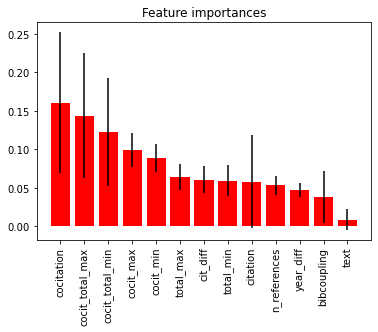

In [94]:
importances = clf.feature_importances_
std = np.std([tree.feature_importances_ for tree in clf.estimators_],
             axis=0)
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")

for f in range(X.shape[1]):
    print("%d. feature %d - %s - (%f)" % (f + 1, indices[f], feature_names[indices[f]], importances[indices[f]]))

# Plot the impurity-based feature importances of the forest
plt.figure()
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices],
        color="r", yerr=std[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[x] for x in indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.show()

## CatBoost

In [65]:
from catboost import Pool, CatBoostClassifier, CatBoost

In [68]:
train_dataset = Pool(data=X, label=y)
eval_dataset = Pool(data=X_eval, label=y_eval)
model = CatBoostClassifier(iterations=1400, use_best_model=True, learning_rate=0.02, max_depth=6)

model.fit(train_dataset,
          use_best_model=True,
          eval_set=eval_dataset)

0:	learn: 0.6904479	test: 0.6914129	best: 0.6914129 (0)	total: 58.9ms	remaining: 1m 22s
1:	learn: 0.6879122	test: 0.6890757	best: 0.6890757 (1)	total: 66ms	remaining: 46.1s
2:	learn: 0.6858081	test: 0.6880532	best: 0.6880532 (2)	total: 72.6ms	remaining: 33.8s
3:	learn: 0.6836859	test: 0.6867555	best: 0.6867555 (3)	total: 79.5ms	remaining: 27.7s
4:	learn: 0.6814307	test: 0.6851763	best: 0.6851763 (4)	total: 86.3ms	remaining: 24.1s
5:	learn: 0.6794729	test: 0.6834542	best: 0.6834542 (5)	total: 92.8ms	remaining: 21.6s
6:	learn: 0.6772714	test: 0.6813707	best: 0.6813707 (6)	total: 99.9ms	remaining: 19.9s
7:	learn: 0.6751201	test: 0.6802266	best: 0.6802266 (7)	total: 107ms	remaining: 18.5s
8:	learn: 0.6732171	test: 0.6786920	best: 0.6786920 (8)	total: 113ms	remaining: 17.5s
9:	learn: 0.6715037	test: 0.6778235	best: 0.6778235 (9)	total: 122ms	remaining: 16.9s
10:	learn: 0.6700387	test: 0.6763906	best: 0.6763906 (10)	total: 129ms	remaining: 16.3s
11:	learn: 0.6685001	test: 0.6752593	best: 0.6

102:	learn: 0.6031481	test: 0.6417628	best: 0.6417606 (101)	total: 865ms	remaining: 10.9s
103:	learn: 0.6027687	test: 0.6416999	best: 0.6416999 (103)	total: 875ms	remaining: 10.9s
104:	learn: 0.6024669	test: 0.6417054	best: 0.6416999 (103)	total: 885ms	remaining: 10.9s
105:	learn: 0.6023012	test: 0.6416484	best: 0.6416484 (105)	total: 896ms	remaining: 10.9s
106:	learn: 0.6020142	test: 0.6414291	best: 0.6414291 (106)	total: 916ms	remaining: 11.1s
107:	learn: 0.6018447	test: 0.6412102	best: 0.6412102 (107)	total: 928ms	remaining: 11.1s
108:	learn: 0.6014097	test: 0.6412904	best: 0.6412102 (107)	total: 936ms	remaining: 11.1s
109:	learn: 0.6010887	test: 0.6413257	best: 0.6412102 (107)	total: 943ms	remaining: 11.1s
110:	learn: 0.6009064	test: 0.6413263	best: 0.6412102 (107)	total: 950ms	remaining: 11s
111:	learn: 0.6006070	test: 0.6412529	best: 0.6412102 (107)	total: 957ms	remaining: 11s
112:	learn: 0.6003280	test: 0.6412636	best: 0.6412102 (107)	total: 964ms	remaining: 11s
113:	learn: 0.59

202:	learn: 0.5727885	test: 0.6455913	best: 0.6412102 (107)	total: 1.66s	remaining: 9.81s
203:	learn: 0.5724887	test: 0.6456823	best: 0.6412102 (107)	total: 1.67s	remaining: 9.81s
204:	learn: 0.5722722	test: 0.6458295	best: 0.6412102 (107)	total: 1.68s	remaining: 9.81s
205:	learn: 0.5718734	test: 0.6457728	best: 0.6412102 (107)	total: 1.69s	remaining: 9.81s
206:	learn: 0.5716092	test: 0.6456550	best: 0.6412102 (107)	total: 1.7s	remaining: 9.81s
207:	learn: 0.5709413	test: 0.6460535	best: 0.6412102 (107)	total: 1.71s	remaining: 9.79s
208:	learn: 0.5705795	test: 0.6461682	best: 0.6412102 (107)	total: 1.72s	remaining: 9.78s
209:	learn: 0.5704095	test: 0.6462693	best: 0.6412102 (107)	total: 1.72s	remaining: 9.76s
210:	learn: 0.5700935	test: 0.6462098	best: 0.6412102 (107)	total: 1.73s	remaining: 9.75s
211:	learn: 0.5699054	test: 0.6462497	best: 0.6412102 (107)	total: 1.74s	remaining: 9.73s
212:	learn: 0.5697317	test: 0.6462229	best: 0.6412102 (107)	total: 1.74s	remaining: 9.72s
213:	learn:

297:	learn: 0.5520736	test: 0.6531119	best: 0.6412102 (107)	total: 2.48s	remaining: 9.19s
298:	learn: 0.5518850	test: 0.6531275	best: 0.6412102 (107)	total: 2.5s	remaining: 9.19s
299:	learn: 0.5517910	test: 0.6532617	best: 0.6412102 (107)	total: 2.5s	remaining: 9.19s
300:	learn: 0.5515802	test: 0.6532865	best: 0.6412102 (107)	total: 2.52s	remaining: 9.19s
301:	learn: 0.5513894	test: 0.6532597	best: 0.6412102 (107)	total: 2.53s	remaining: 9.19s
302:	learn: 0.5511846	test: 0.6532301	best: 0.6412102 (107)	total: 2.54s	remaining: 9.18s
303:	learn: 0.5509954	test: 0.6530894	best: 0.6412102 (107)	total: 2.54s	remaining: 9.17s
304:	learn: 0.5508296	test: 0.6530720	best: 0.6412102 (107)	total: 2.56s	remaining: 9.2s
305:	learn: 0.5506828	test: 0.6530678	best: 0.6412102 (107)	total: 2.57s	remaining: 9.2s
306:	learn: 0.5506389	test: 0.6530842	best: 0.6412102 (107)	total: 2.59s	remaining: 9.21s
307:	learn: 0.5505556	test: 0.6532415	best: 0.6412102 (107)	total: 2.6s	remaining: 9.23s
308:	learn: 0.5

412:	learn: 0.5319784	test: 0.6609050	best: 0.6412102 (107)	total: 3.72s	remaining: 8.9s
413:	learn: 0.5317269	test: 0.6609614	best: 0.6412102 (107)	total: 3.74s	remaining: 8.9s
414:	learn: 0.5315547	test: 0.6609011	best: 0.6412102 (107)	total: 3.75s	remaining: 8.89s
415:	learn: 0.5313127	test: 0.6609075	best: 0.6412102 (107)	total: 3.76s	remaining: 8.9s
416:	learn: 0.5311404	test: 0.6611480	best: 0.6412102 (107)	total: 3.77s	remaining: 8.9s
417:	learn: 0.5309055	test: 0.6611805	best: 0.6412102 (107)	total: 3.79s	remaining: 8.9s
418:	learn: 0.5306917	test: 0.6618488	best: 0.6412102 (107)	total: 3.8s	remaining: 8.9s
419:	learn: 0.5305075	test: 0.6621181	best: 0.6412102 (107)	total: 3.81s	remaining: 8.89s
420:	learn: 0.5303918	test: 0.6620602	best: 0.6412102 (107)	total: 3.82s	remaining: 8.88s
421:	learn: 0.5303013	test: 0.6620229	best: 0.6412102 (107)	total: 3.83s	remaining: 8.87s
422:	learn: 0.5299258	test: 0.6622190	best: 0.6412102 (107)	total: 3.85s	remaining: 8.9s
423:	learn: 0.5297

...

927:	learn: 0.4457052	test: 0.7227548	best: 0.6412102 (107)	total: 8.15s	remaining: 4.15s
928:	learn: 0.4455803	test: 0.7227203	best: 0.6412102 (107)	total: 8.16s	remaining: 4.14s
929:	learn: 0.4454382	test: 0.7227705	best: 0.6412102 (107)	total: 8.17s	remaining: 4.13s
930:	learn: 0.4453374	test: 0.7228040	best: 0.6412102 (107)	total: 8.18s	remaining: 4.12s
931:	learn: 0.4451231	test: 0.7234156	best: 0.6412102 (107)	total: 8.19s	remaining: 4.11s
932:	learn: 0.4449533	test: 0.7233869	best: 0.6412102 (107)	total: 8.2s	remaining: 4.1s
933:	learn: 0.4448578	test: 0.7234458	best: 0.6412102 (107)	total: 8.2s	remaining: 4.09s
934:	learn: 0.4447033	test: 0.7234870	best: 0.6412102 (107)	total: 8.21s	remaining: 4.08s
935:	learn: 0.4445730	test: 0.7235176	best: 0.6412102 (107)	total: 8.22s	remaining: 4.07s
936:	learn: 0.4445162	test: 0.7235159	best: 0.6412102 (107)	total: 8.22s	remaining: 4.06s
937:	learn: 0.4444788	test: 0.7239836	best: 0.6412102 (107)	total: 8.23s	remaining: 4.05s
938:	learn: 0

1039:	learn: 0.4313091	test: 0.7329335	best: 0.6412102 (107)	total: 9.16s	remaining: 3.17s
1040:	learn: 0.4311595	test: 0.7327312	best: 0.6412102 (107)	total: 9.18s	remaining: 3.16s
1041:	learn: 0.4310882	test: 0.7327386	best: 0.6412102 (107)	total: 9.19s	remaining: 3.15s
1042:	learn: 0.4309885	test: 0.7327651	best: 0.6412102 (107)	total: 9.19s	remaining: 3.15s
1043:	learn: 0.4309703	test: 0.7328950	best: 0.6412102 (107)	total: 9.21s	remaining: 3.14s
1044:	learn: 0.4308069	test: 0.7329550	best: 0.6412102 (107)	total: 9.22s	remaining: 3.13s
1045:	learn: 0.4307209	test: 0.7330502	best: 0.6412102 (107)	total: 9.23s	remaining: 3.12s
1046:	learn: 0.4305631	test: 0.7330780	best: 0.6412102 (107)	total: 9.24s	remaining: 3.12s
1047:	learn: 0.4304599	test: 0.7330987	best: 0.6412102 (107)	total: 9.25s	remaining: 3.11s
1048:	learn: 0.4303745	test: 0.7333551	best: 0.6412102 (107)	total: 9.26s	remaining: 3.1s
1049:	learn: 0.4302516	test: 0.7333389	best: 0.6412102 (107)	total: 9.26s	remaining: 3.09s


1137:	learn: 0.4196961	test: 0.7419480	best: 0.6412102 (107)	total: 9.98s	remaining: 2.3s
1138:	learn: 0.4196319	test: 0.7420656	best: 0.6412102 (107)	total: 9.99s	remaining: 2.29s
1139:	learn: 0.4195679	test: 0.7420953	best: 0.6412102 (107)	total: 10s	remaining: 2.28s
1140:	learn: 0.4195505	test: 0.7422129	best: 0.6412102 (107)	total: 10s	remaining: 2.27s
1141:	learn: 0.4194131	test: 0.7422973	best: 0.6412102 (107)	total: 10s	remaining: 2.26s
1142:	learn: 0.4193435	test: 0.7425563	best: 0.6412102 (107)	total: 10s	remaining: 2.25s
1143:	learn: 0.4192433	test: 0.7426184	best: 0.6412102 (107)	total: 10s	remaining: 2.25s
1144:	learn: 0.4190925	test: 0.7424798	best: 0.6412102 (107)	total: 10s	remaining: 2.24s
1145:	learn: 0.4190294	test: 0.7424656	best: 0.6412102 (107)	total: 10s	remaining: 2.23s
1146:	learn: 0.4190043	test: 0.7425587	best: 0.6412102 (107)	total: 10.1s	remaining: 2.22s
1147:	learn: 0.4188572	test: 0.7430470	best: 0.6412102 (107)	total: 10.1s	remaining: 2.21s
1148:	learn: 0

1250:	learn: 0.4082452	test: 0.7547627	best: 0.6412102 (107)	total: 11s	remaining: 1.31s
1251:	learn: 0.4081690	test: 0.7547809	best: 0.6412102 (107)	total: 11s	remaining: 1.3s
1252:	learn: 0.4080479	test: 0.7548451	best: 0.6412102 (107)	total: 11s	remaining: 1.29s
1253:	learn: 0.4079694	test: 0.7549089	best: 0.6412102 (107)	total: 11s	remaining: 1.28s
1254:	learn: 0.4078386	test: 0.7548793	best: 0.6412102 (107)	total: 11s	remaining: 1.27s
1255:	learn: 0.4077067	test: 0.7549125	best: 0.6412102 (107)	total: 11.1s	remaining: 1.27s
1256:	learn: 0.4076018	test: 0.7549058	best: 0.6412102 (107)	total: 11.1s	remaining: 1.26s
1257:	learn: 0.4075232	test: 0.7549905	best: 0.6412102 (107)	total: 11.1s	remaining: 1.25s
1258:	learn: 0.4075081	test: 0.7549729	best: 0.6412102 (107)	total: 11.1s	remaining: 1.24s
1259:	learn: 0.4074414	test: 0.7549437	best: 0.6412102 (107)	total: 11.1s	remaining: 1.23s
1260:	learn: 0.4073899	test: 0.7549684	best: 0.6412102 (107)	total: 11.1s	remaining: 1.22s
1261:	lear

1367:	learn: 0.3967607	test: 0.7636449	best: 0.6412102 (107)	total: 12s	remaining: 281ms
1368:	learn: 0.3967495	test: 0.7638310	best: 0.6412102 (107)	total: 12s	remaining: 273ms
1369:	learn: 0.3966294	test: 0.7638586	best: 0.6412102 (107)	total: 12s	remaining: 264ms
1370:	learn: 0.3965643	test: 0.7638179	best: 0.6412102 (107)	total: 12.1s	remaining: 255ms
1371:	learn: 0.3964321	test: 0.7637800	best: 0.6412102 (107)	total: 12.1s	remaining: 246ms
1372:	learn: 0.3963858	test: 0.7637103	best: 0.6412102 (107)	total: 12.1s	remaining: 237ms
1373:	learn: 0.3963436	test: 0.7637022	best: 0.6412102 (107)	total: 12.1s	remaining: 229ms
1374:	learn: 0.3962432	test: 0.7640604	best: 0.6412102 (107)	total: 12.1s	remaining: 220ms
1375:	learn: 0.3961967	test: 0.7639404	best: 0.6412102 (107)	total: 12.1s	remaining: 211ms
1376:	learn: 0.3961639	test: 0.7639399	best: 0.6412102 (107)	total: 12.1s	remaining: 202ms
1377:	learn: 0.3960505	test: 0.7640315	best: 0.6412102 (107)	total: 12.1s	remaining: 193ms
1378:

In [70]:
print(f"R^2: {model.score(X, y)} validate: {model.score(X_eval, y_eval)}")

R^2: 0.6845355731225297 validate: 0.5961173643606931


In [76]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(model.predict(X_eval), y_eval))
print(accuracy_score(model.predict(X_eval), y_eval))

[[3730 2210]
 [4177 5697]]
0.5961173643606931


In [77]:
importances = model.get_feature_importance(data=train_dataset,
                       prettified=True,
                       thread_count=-1,
                       verbose=False)

In [78]:
importances

,Feature Id,Importances
0,cocit_max,19.626431
1,cocit_total_min,15.422370
2,cocit_total_max,12.207878
3,cocit_min,10.347167
4,bibcoupling,7.909915
5,cocitation,7.398299
6,citation,7.154786
7,total_min,6.330713
8,year_diff,5.803952
9,total_max,5.032661
